#  ERK vs. AKT Propagation Comparison
Hypothesis: ERK and AKT biosensors report on different signaling pathways that may
exhibit distinct spatiotemporal propagation patterns.

#### 1. Imports and paths 

In [37]:
from pathlib import Path
import sys
import subprocess
import json

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path("..").resolve()

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_PATH = PROJECT_ROOT / "data" / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = PROJECT_ROOT / "data" / "01-readme-experiment-description_2022-04-05.csv"

OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs"
FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_ROOT.mkdir(exist_ok=True)
FINAL_OUTPUT_DIR.mkdir(exist_ok=True)

print("DATA exists:", DATA_PATH.exists())
print("META exists:", META_PATH.exists())
print("SCRIPT exists:", (SCRIPTS_DIR / "spatiotemporal_signal_propagation.py").exists())



DATA exists: True
META exists: True
SCRIPT exists: True


#### 2. Metadata loading and block selection

In [ ]:
# Select same experiment-site blocks for both biosensors
meta = pd.read_csv(META_PATH, encoding="utf-8-sig")
meta = meta.rename(columns={"Site": "Image_Metadata_Site"})

selected_mutations = ["WT", "AKT1_E17K", "PTEN_del"]

# Get all valid experiment-site pairs that actually exist in the tracking data.
tracks_blocks = (
    pd.read_csv(
        DATA_PATH,
        usecols=["Exp_ID", "Image_Metadata_Site"]
    )
    .drop_duplicates()
    .rename(columns={
        "Exp_ID": "exp_id",
        "Image_Metadata_Site": "site_id"
    })
)

# Select all metadata sites for the chosen mutations.
selected_sites = (
    meta[meta["Mutation"].isin(selected_mutations)]
    [["Mutation", "Image_Metadata_Site"]]
    .drop_duplicates()
    .rename(columns={
        "Mutation": "mutation",
        "Image_Metadata_Site": "site_id"
    })
)

# Match selected mutation sites with real exp_id/site_id pairs from the tracking data.
selected_blocks = (
    selected_sites
    .merge(tracks_blocks, on="site_id", how="inner")
    [["mutation", "exp_id", "site_id"]]
    .sort_values(["mutation", "exp_id", "site_id"])
    .reset_index(drop=True)
)

selected_blocks["exp_id"] = selected_blocks["exp_id"].astype(int)
selected_blocks["site_id"] = selected_blocks["site_id"].astype(int)

print(f"Selected valid experiment-site blocks: {len(selected_blocks)}")
print(selected_blocks.to_string(index=False))

Selected valid experiment-site blocks: 72
 mutation  exp_id  site_id
AKT1_E17K       1        5
AKT1_E17K       1        6
AKT1_E17K       1        7
AKT1_E17K       1        8
AKT1_E17K       2        7
AKT1_E17K       2        8
AKT1_E17K       3        5
AKT1_E17K       3        6
AKT1_E17K       3        7
AKT1_E17K       3        8
AKT1_E17K       4        5
AKT1_E17K       4        6
AKT1_E17K       4        7
AKT1_E17K       4        8
AKT1_E17K       5        6
AKT1_E17K       5        7
AKT1_E17K       5        8
AKT1_E17K       6        5
AKT1_E17K       6        6
AKT1_E17K       6        7
AKT1_E17K       6        8
 PTEN_del       1       17
 PTEN_del       1       18
 PTEN_del       1       19
 PTEN_del       1       20
 PTEN_del       2       17
 PTEN_del       2       18
 PTEN_del       2       19
 PTEN_del       2       20
 PTEN_del       3       17
 PTEN_del       3       18
 PTEN_del       3       19
 PTEN_del       3       20
 PTEN_del       4       17
 PTEN_del    

In [22]:
meta = pd.read_csv(META_PATH, encoding="utf-8-sig")
meta = meta.rename(columns={"Site": "Image_Metadata_Site"})

add_mutations = ["PIK3CA_E545K", "PIK3CA_H1047R"]

tracks_blocks = (
    pd.read_csv(
        DATA_PATH,
        usecols=["Exp_ID", "Image_Metadata_Site"]
    )
    .drop_duplicates()
    .rename(columns={
        "Exp_ID": "exp_id",
        "Image_Metadata_Site": "site_id"
    })
)

add_sites = (
    meta[meta["Mutation"].isin(add_mutations)]
    [["Mutation", "Image_Metadata_Site"]]
    .drop_duplicates()
    .rename(columns={
        "Mutation": "mutation",
        "Image_Metadata_Site": "site_id"
    })
)

# Match selected mutation sites with real exp_id/site_id pairs from the tracking data.
add_blocks = (
    add_sites
    .merge(tracks_blocks, on="site_id", how="inner")
    [["mutation", "exp_id", "site_id"]]
    .sort_values(["mutation", "exp_id", "site_id"])
    .reset_index(drop=True)
)

add_blocks["exp_id"] = add_blocks["exp_id"].astype(int)
add_blocks["site_id"] = add_blocks["site_id"].astype(int)

print(f"Selected valid experiment-site blocks: {len(add_blocks)}")
print(add_blocks.to_string(index=False))

Selected valid experiment-site blocks: 48
     mutation  exp_id  site_id
 PIK3CA_E545K       1        9
 PIK3CA_E545K       1       10
 PIK3CA_E545K       1       11
 PIK3CA_E545K       1       12
 PIK3CA_E545K       2        9
 PIK3CA_E545K       2       10
 PIK3CA_E545K       2       11
 PIK3CA_E545K       2       12
 PIK3CA_E545K       3        9
 PIK3CA_E545K       3       10
 PIK3CA_E545K       3       11
 PIK3CA_E545K       3       12
 PIK3CA_E545K       4        9
 PIK3CA_E545K       4       10
 PIK3CA_E545K       4       11
 PIK3CA_E545K       4       12
 PIK3CA_E545K       5        9
 PIK3CA_E545K       5       10
 PIK3CA_E545K       5       11
 PIK3CA_E545K       5       12
 PIK3CA_E545K       6        9
 PIK3CA_E545K       6       10
 PIK3CA_E545K       6       11
 PIK3CA_E545K       6       12
PIK3CA_H1047R       1       13
PIK3CA_H1047R       1       14
PIK3CA_H1047R       1       15
PIK3CA_H1047R       1       16
PIK3CA_H1047R       2       13
PIK3CA_H1047R       2       

The first table shows available mutations and imaging sites present in the metadata.  
The second table contains the experiment-site blocks selected for downstream analysis.

#### 3. Running propagation analysis for both biosensors
The spatiotemporal propagation pipeline is executed separately for `ERKKTR_ratio` and `FoxO3A_ratio` using identical analysis parameters and the same experiment-site blocks.

In [39]:
signals = {
    "ERKKTR_ratio": "ERKKTR_ratio",
    "FoxO3A_ratio": "FoxO3A_ratio"
}

SPATIAL_RADIUS = 60
FUTURE_WINDOW = 3
JUMP_QUANTILE = 0.9

rows = []

for block in selected_blocks.itertuples(index=False):
    for signal_label, signal_col in signals.items():
        
        outdir = (OUTPUT_ROOT /f"TaskB_{block.mutation}_exp{block.exp_id}_site{block.site_id}_{signal_label}")
        
        cmd = [
            sys.executable,
            str(SCRIPTS_DIR / "spatiotemporal_signal_propagation.py"),
            "--data-path", str(DATA_PATH),
            "--meta-path", str(META_PATH),
            "--exp-id", str(block.exp_id),
            "--site-id", str(block.site_id),
            "--signal-col", signal_col,
            "--spatial-radius", str(SPATIAL_RADIUS),
            "--future-window-frames", str(FUTURE_WINDOW),
            "--jump-quantile", str(JUMP_QUANTILE),
            "--output-dir", str(outdir),
        ]
        
        print(f"Running {block.mutation} | {signal_label}")
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            print(result.stderr)
            raise RuntimeError(f"Script failed for {block.mutation} | {signal_label}")
        
        summary_path = (
            outdir /
            f"exp_{block.exp_id}_site_{block.site_id}_{signal_col}" /
            "summary.json"
        )
        
        with open(summary_path) as f:
            s = json.load(f)
        
        rows.append({
            "mutation": block.mutation,
            "exp_id": block.exp_id,
            "site_id": block.site_id,
            "biosensor": signal_label,
            "signal_col": signal_col,
            "jump_threshold_theta": s["jump_threshold"],
            "p_exposed": s["future_jump_rate_if_neighbor_jumps_now"],
            "p_unexposed": s["future_jump_rate_if_no_neighbor_jumps_now"],
            "risk_difference": s["risk_difference"],
            "RR": s["relative_risk"],
            "n_nodes": s["n_nodes"],
            "n_spatial_edges": s["n_spatial_edges"],
        })

b1_df = pd.DataFrame(rows)
display(b1_df)

# Calculate mean propagation statistics across blocks.
summary_df = (
    b1_df
    .groupby(["mutation", "biosensor"], as_index=False)
    .agg(
        mean_RR=("RR", "mean"),
        std_RR=("RR", "std"),
        mean_theta=("jump_threshold_theta", "mean"),
        n_blocks=("RR", "count")
    )
)

display(summary_df)

Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AK

,mutation,exp_id,site_id,biosensor,signal_col,jump_threshold_theta,p_exposed,p_unexposed,risk_difference,RR,n_nodes,n_spatial_edges
0,AKT1_E17K,1,5,ERKKTR_ratio,ERKKTR_ratio,0.022628,0.155272,0.096390,0.058883,1.610885,448311,3863383
1,AKT1_E17K,1,5,FoxO3A_ratio,FoxO3A_ratio,0.046550,0.152510,0.118690,0.033820,1.284947,448311,3863383
2,AKT1_E17K,1,6,ERKKTR_ratio,ERKKTR_ratio,0.021569,0.166842,0.083748,0.083094,1.992198,440567,3882605
3,AKT1_E17K,1,6,FoxO3A_ratio,FoxO3A_ratio,0.044560,0.158121,0.112229,0.045892,1.408911,440567,3882605
4,AKT1_E17K,1,7,ERKKTR_ratio,ERKKTR_ratio,0.023369,0.171658,0.073368,0.098290,2.339684,382261,2803597
...,...,...,...,...,...,...,...,...,...,...,...,...
139,WT,6,2,FoxO3A_ratio,FoxO3A_ratio,0.030258,0.155876,0.117014,0.038862,1.332118,292522,1612541
140,WT,6,3,ERKKTR_ratio,ERKKTR_ratio,0.049485,0.138148,0.074931,0.063217,1.843681,284116,1515115
141,WT,6,3,FoxO3A_ratio,FoxO3A_ratio,0.032181,0.158696,0.113671,0.045025,1.396096,284116,1515115
142,WT,6,4,ERKKTR_ratio,ERKKTR_ratio,0.047200,0.132513,0.078721,0.053792,1.683328,318206,1917620


,mutation,biosensor,mean_RR,std_RR,mean_theta,n_blocks
0,AKT1_E17K,ERKKTR_ratio,1.581421,0.329635,0.020493,21
1,AKT1_E17K,FoxO3A_ratio,1.272374,0.080330,0.042547,21
2,PTEN_del,ERKKTR_ratio,1.556633,0.112361,0.071923,27
3,PTEN_del,FoxO3A_ratio,1.401192,0.127419,0.049894,27
4,WT,ERKKTR_ratio,1.742349,0.084226,0.048879,24
5,WT,FoxO3A_ratio,1.373404,0.093429,0.034558,24


In [23]:
signals = {
    "ERKKTR_ratio": "ERKKTR_ratio",
    "FoxO3A_ratio": "FoxO3A_ratio"
}

SPATIAL_RADIUS = 60
FUTURE_WINDOW = 3
JUMP_QUANTILE = 0.9

rows = []

for block in add_blocks.itertuples(index=False):
    for signal_label, signal_col in signals.items():
        
        outdir = (OUTPUT_ROOT /f"TaskB_add_{block.mutation}_exp{block.exp_id}_site{block.site_id}_{signal_label}")
        
        cmd = [
            sys.executable,
            str(SCRIPTS_DIR / "spatiotemporal_signal_propagation.py"),
            "--data-path", str(DATA_PATH),
            "--meta-path", str(META_PATH),
            "--exp-id", str(block.exp_id),
            "--site-id", str(block.site_id),
            "--signal-col", signal_col,
            "--spatial-radius", str(SPATIAL_RADIUS),
            "--future-window-frames", str(FUTURE_WINDOW),
            "--jump-quantile", str(JUMP_QUANTILE),
            "--output-dir", str(outdir),
        ]
        
        print(f"Running {block.mutation} | {signal_label}")
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            print(result.stderr)
            raise RuntimeError(f"Script failed for {block.mutation} | {signal_label}")
        
        summary_path = (
            outdir /
            f"exp_{block.exp_id}_site_{block.site_id}_{signal_col}" /
            "summary.json"
        )
        
        with open(summary_path) as f:
            s = json.load(f)
        
        rows.append({
            "mutation": block.mutation,
            "exp_id": block.exp_id,
            "site_id": block.site_id,
            "biosensor": signal_label,
            "signal_col": signal_col,
            "jump_threshold_theta": s["jump_threshold"],
            "p_exposed": s["future_jump_rate_if_neighbor_jumps_now"],
            "p_unexposed": s["future_jump_rate_if_no_neighbor_jumps_now"],
            "risk_difference": s["risk_difference"],
            "RR": s["relative_risk"],
            "n_nodes": s["n_nodes"],
            "n_spatial_edges": s["n_spatial_edges"],
        })

b1_df = pd.DataFrame(rows)
display(b1_df)

# Calculate mean propagation statistics across blocks.
summary_df = (
    b1_df
    .groupby(["mutation", "biosensor"], as_index=False)
    .agg(
        mean_RR=("RR", "mean"),
        std_RR=("RR", "std"),
        mean_theta=("jump_threshold_theta", "mean"),
        n_blocks=("RR", "count")
    )
)

display(summary_df)

Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3A_ratio
Running PIK3CA_E545K | ERKKTR_ratio
Running PIK3CA_E545K | FoxO3

,mutation,exp_id,site_id,biosensor,signal_col,jump_threshold_theta,p_exposed,p_unexposed,risk_difference,RR,n_nodes,n_spatial_edges
0,PIK3CA_E545K,1,9,ERKKTR_ratio,ERKKTR_ratio,0.046054,0.139907,0.086022,0.053885,1.626404,326279,1995173
1,PIK3CA_E545K,1,9,FoxO3A_ratio,FoxO3A_ratio,0.037690,0.149513,0.111939,0.037574,1.335667,326279,1995173
2,PIK3CA_E545K,1,10,ERKKTR_ratio,ERKKTR_ratio,0.050958,0.146183,0.083238,0.062945,1.756197,344904,2269778
3,PIK3CA_E545K,1,10,FoxO3A_ratio,FoxO3A_ratio,0.041690,0.157757,0.108211,0.049545,1.457859,344904,2269778
4,PIK3CA_E545K,1,11,ERKKTR_ratio,ERKKTR_ratio,0.049790,0.136836,0.090225,0.046611,1.516613,343420,2219451
...,...,...,...,...,...,...,...,...,...,...,...,...
91,PIK3CA_H1047R,6,14,FoxO3A_ratio,FoxO3A_ratio,0.134994,0.245184,0.062014,0.183170,3.953681,180948,607606
92,PIK3CA_H1047R,6,15,ERKKTR_ratio,ERKKTR_ratio,0.157172,0.249754,0.055807,0.193947,4.475321,193447,680904
93,PIK3CA_H1047R,6,15,FoxO3A_ratio,FoxO3A_ratio,0.101550,0.242480,0.065054,0.177426,3.727356,193447,680904
94,PIK3CA_H1047R,6,16,ERKKTR_ratio,ERKKTR_ratio,0.136902,0.208275,0.062876,0.145399,3.312463,215604,869122


,mutation,biosensor,mean_RR,std_RR,mean_theta,n_blocks
0,PIK3CA_E545K,ERKKTR_ratio,1.707110,0.156202,0.050400,24
1,PIK3CA_E545K,FoxO3A_ratio,1.463307,0.159963,0.044008,24
2,PIK3CA_H1047R,ERKKTR_ratio,3.200310,0.640017,0.134224,24
3,PIK3CA_H1047R,FoxO3A_ratio,2.624011,0.636056,0.096729,24


#### 4. Save comparison table

In [24]:
b1_df.to_csv(FINAL_OUTPUT_DIR / "B1_add_ERK_vs_AKT_comparison_table.csv", index=False)

print("Saved:")
print(FINAL_OUTPUT_DIR / "B1_add_ERK_vs_AKT_comparison_table.csv")

Saved:
/Users/alicja/Documents/BS2-Spatiotemporal/outputs/B1_add_ERK_vs_AKT_comparison_table.csv


In [31]:
import pandas as pd

# Read the saved comparison table back into a DataFrame
b1_read_df = pd.read_csv(FINAL_OUTPUT_DIR / "B1_ERK_vs_AKT_comparison_table.csv")
add_df = pd.read_csv(FINAL_OUTPUT_DIR / "B1_add_ERK_vs_AKT_comparison_table.csv")

b1_concat_df = pd.concat([b1_read_df, add_df], ignore_index=True)
b1_concat_df.to_csv(FINAL_OUTPUT_DIR / "B1_concat_ERK_vs_AKT_comparison_table.csv", index=False)
print("Saved concatenated comparison table to:")
print(FINAL_OUTPUT_DIR / "B1_concat_ERK_vs_AKT_comparison_table.csv")

summary_df = (
    b1_concat_df
    .groupby(["mutation", "biosensor"], as_index=False)
    .agg(
        mean_RR=("RR", "mean"),
        std_RR=("RR", "std"),
        mean_theta=("jump_threshold_theta", "mean"),
        n_blocks=("RR", "count")
    )
)
summary_df

Saved concatenated comparison table to:
/Users/alicja/Documents/BS2-Spatiotemporal/outputs/B1_concat_ERK_vs_AKT_comparison_table.csv


,mutation,biosensor,mean_RR,std_RR,mean_theta,n_blocks
0,AKT1_E17K,ERKKTR_ratio,1.581421,0.329635,0.020493,21
1,AKT1_E17K,FoxO3A_ratio,1.272374,0.080330,0.042547,21
2,PIK3CA_E545K,ERKKTR_ratio,1.707110,0.156202,0.050400,24
3,PIK3CA_E545K,FoxO3A_ratio,1.463307,0.159963,0.044008,24
4,PIK3CA_H1047R,ERKKTR_ratio,3.200310,0.640017,0.134224,24
5,PIK3CA_H1047R,FoxO3A_ratio,2.624011,0.636056,0.096729,24
6,PTEN_del,ERKKTR_ratio,1.556633,0.112361,0.071923,27
7,PTEN_del,FoxO3A_ratio,1.401192,0.127419,0.049894,27
8,WT,ERKKTR_ratio,1.742349,0.084226,0.048879,24
9,WT,FoxO3A_ratio,1.373404,0.093429,0.034558,24


#### 5. Visualizing RR differences between biosensors

biosensor,ERKKTR_ratio,FoxO3A_ratio
mutation,,
AKT1_E17K,1.581421,1.272374
PIK3CA_E545K,1.707110,1.463307
PIK3CA_H1047R,3.200310,2.624011
PTEN_del,1.556633,1.401192
WT,1.742349,1.373404


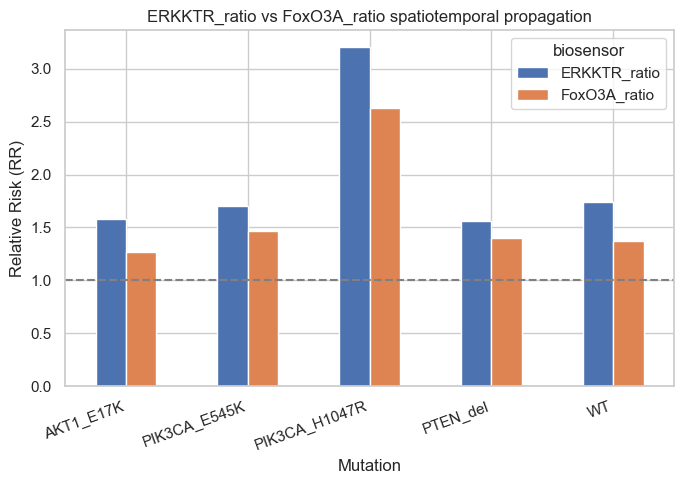

In [28]:
plot_df = summary_df.pivot(
    index="mutation",
    columns="biosensor",
    values="mean_RR"
)

display(plot_df)

fig, ax = plt.subplots(figsize=(7, 5))

plot_df.plot(
    kind="bar",
    ax=ax
)

ax.axhline(1, linestyle="--", color="gray")

ax.set_ylabel("Relative Risk (RR)")
ax.set_xlabel("Mutation")
ax.set_title("ERKKTR_ratio vs FoxO3A_ratio spatiotemporal propagation")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "B1_ERK_vs_FoxO3A_RR_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 6. Visualizing jump thresholds

biosensor,ERKKTR_ratio,FoxO3A_ratio
mutation,,
AKT1_E17K,0.020493,0.042547
PIK3CA_E545K,0.050400,0.044008
PIK3CA_H1047R,0.134224,0.096729
PTEN_del,0.071923,0.049894
WT,0.048879,0.034558


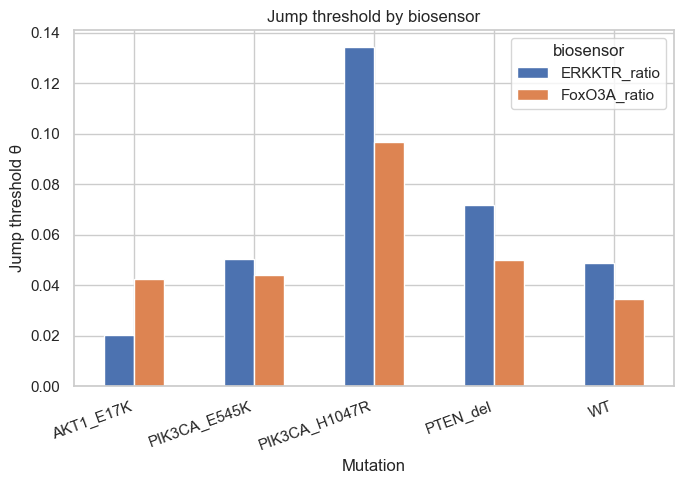

In [29]:
theta_df = summary_df.pivot(
    index="mutation",
    columns="biosensor",
    values="mean_theta"
)

fig, ax = plt.subplots(figsize=(7, 5))

theta_df.plot(
    kind="bar",
    ax=ax
)

display(theta_df)

ax.set_ylabel("Jump threshold θ")
ax.set_xlabel("Mutation")
ax.set_title("Jump threshold by biosensor")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "B1_ERK_vs_FoxO3A_theta_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 7. Overall interpretation

In [30]:
erk_mean = b1_df[b1_df["biosensor"] == "ERKKTR_ratio"]["RR"].mean()
akt_mean = b1_df[b1_df["biosensor"] == "FoxO3A_ratio"]["RR"].mean()

print(f"Mean RR for ERKKTR_ratio: {erk_mean:.3f}")
print(f"Mean RR for FoxO3A_ratio: {akt_mean:.3f}")

if erk_mean > akt_mean:
    print("ERKKTR_ratio shows stronger average spatiotemporal propagation than FoxO3A_ratio.")
elif akt_mean > erk_mean:
    print("FoxO3A_ratio shows stronger average spatiotemporal propagation than ERKKTR_ratio.")
else:
    print("Both biosensors show similar average propagation strength.")

Mean RR for ERKKTR_ratio: 2.454
Mean RR for FoxO3A_ratio: 2.044
ERKKTR_ratio shows stronger average spatiotemporal propagation than FoxO3A_ratio.


In [33]:
import numpy as np
from scipy.stats import mannwhitneyu

# liczymy srednia i odchylenie standardowe
comp_stats = b1_concat_df.groupby(['mutation', 'biosensor'])['RR'].agg(['mean', 'std', 'count']).reset_index()
comp_stats = comp_stats.rename(columns={'mean': 'mean_RR', 'std': 'std_RR', 'count': 'n_blocks'})

mannwhitney_rows = []

# dla kazdego biomarkera obliczamy statystyke w porowaniu do wt
for biosensor in b1_concat_df['biosensor'].unique():
    df_bio = b1_concat_df[b1_concat_df['biosensor'] == biosensor]
    wt_RR = df_bio[df_bio['mutation'] == 'WT']['RR']
    for mutation in df_bio['mutation'].unique():
        if mutation == 'WT':
            continue
        mut_RR = df_bio[df_bio['mutation'] == mutation]['RR']
        stat, pval = mannwhitneyu(wt_RR, mut_RR, alternative='two-sided')
        mannwhitney_rows.append({
            'mutation': mutation,
            'biosensor': biosensor,
            'statistic': stat,
            'p_raw': pval,
            'mean_RR_mutation': mut_RR.mean(),
            'mean_RR_WT': wt_RR.mean()
        })
mannwhitney_df = pd.DataFrame(mannwhitney_rows)

# robimy poprawke na wiele testow = bonferroni
alpha = 0.05
for biosensor in b1_concat_df['biosensor'].unique():
    ntest = (mannwhitney_df['biosensor'] == biosensor).sum()
    mask = mannwhitney_df['biosensor'] == biosensor
    adjusted_alpha = alpha / ntest if ntest else alpha
    mannwhitney_df.loc[mask, 'significant'] = mannwhitney_df.loc[mask, 'p_raw'] < adjusted_alpha

mutations_comparison_table = comp_stats.merge(
    mannwhitney_df[['mutation', 'biosensor', 'p_raw', 'significant']],
    on=['mutation', 'biosensor'],
    how='left'
)

mutations_comparison_table.to_csv(str(FINAL_OUTPUT_DIR)+ '/mutations_comparison_table.csv', index=False)
mutations_comparison_table

,mutation,biosensor,mean_RR,std_RR,n_blocks,p_raw,significant
0,AKT1_E17K,ERKKTR_ratio,1.581421,0.329635,21,3.461467e-03,True
1,AKT1_E17K,FoxO3A_ratio,1.272374,0.080330,21,8.591790e-04,True
2,PIK3CA_E545K,ERKKTR_ratio,1.707110,0.156202,24,1.835290e-01,False
3,PIK3CA_E545K,FoxO3A_ratio,1.463307,0.159963,24,2.395489e-02,False
4,PIK3CA_H1047R,ERKKTR_ratio,3.200310,0.640017,24,3.063664e-09,True
5,PIK3CA_H1047R,FoxO3A_ratio,2.624011,0.636056,24,3.063664e-09,True
6,PTEN_del,ERKKTR_ratio,1.556633,0.112361,27,3.660584e-07,True
7,PTEN_del,FoxO3A_ratio,1.401192,0.127419,27,6.574221e-01,False
8,WT,ERKKTR_ratio,1.742349,0.084226,24,NaN,NaN
9,WT,FoxO3A_ratio,1.373404,0.093429,24,NaN,NaN


In [34]:
import numpy as np
from scipy.stats import mannwhitneyu

# liczymy srednia i odchylenie standardowe
comp_stats = b1_concat_df.groupby(['mutation', 'biosensor'])['RR'].agg(['mean', 'std', 'count']).reset_index()
comp_stats = comp_stats.rename(columns={'mean': 'mean_RR', 'std': 'std_RR', 'count': 'n_blocks'})

mannwhitney_rows = []

# dla każdej mutacji porownujemy fox vs erk
for mutation in b1_concat_df['mutation'].unique():
    df_mut = b1_concat_df[b1_concat_df['mutation'] == mutation]
    erkktr_rr = df_mut[df_mut['biosensor'] == 'ERKKTR_ratio']['RR']
    foxo_rr = df_mut[df_mut['biosensor'] == 'FoxO3A_ratio']['RR']

    if len(erkktr_rr) > 0 and len(foxo_rr) > 0:
        stat, pval = mannwhitneyu(erkktr_rr, foxo_rr, alternative='two-sided')
        mannwhitney_rows.append({
            'mutation': mutation,
            'biosensor_A': 'ERKKTR_ratio',
            'biosensor_B': 'FoxO3A_ratio',
            'statistic': stat,
            'p_raw': pval,
            'mean_RR_ERKKTR': erkktr_rr.mean(),
            'mean_RR_FoxO': foxo_rr.mean(),
            'std_RR_ERKKTR': erkktr_rr.std(),
            'std_RR_FoxO': foxo_rr.std()
        })

mannwhitney_df = pd.DataFrame(mannwhitney_rows)

# poprawka na wielokrotne testowanie (bonferroni)
alpha = 0.05
ntest = len(mannwhitney_df)
adjusted_alpha = alpha / ntest if ntest else alpha
mannwhitney_df['significant'] = mannwhitney_df['p_raw'] < adjusted_alpha

mannwhitney_df.to_csv(str(FINAL_OUTPUT_DIR) + '/compare_rr_wzg_mutacji.csv', index=False)
mannwhitney_df

,mutation,biosensor_A,biosensor_B,statistic,p_raw,mean_RR_ERKKTR,mean_RR_FoxO,std_RR_ERKKTR,std_RR_FoxO,significant
0,AKT1_E17K,ERKKTR_ratio,FoxO3A_ratio,385.0,3.698637e-05,1.581421,1.272374,0.329635,0.080330,True
1,PTEN_del,ERKKTR_ratio,FoxO3A_ratio,628.0,5.367299e-06,1.556633,1.401192,0.112361,0.127419,True
2,WT,ERKKTR_ratio,FoxO3A_ratio,576.0,3.063664e-09,1.742349,1.373404,0.084226,0.093429,True
3,PIK3CA_E545K,ERKKTR_ratio,FoxO3A_ratio,523.0,1.329393e-06,1.707110,1.463307,0.156202,0.159963,True
4,PIK3CA_H1047R,ERKKTR_ratio,FoxO3A_ratio,424.0,5.206645e-03,3.200310,2.624011,0.640017,0.636056,True


In [35]:
import numpy as np
from scipy.stats import mannwhitneyu

# porowanie dla wszystkich mutacji łącznie
erkktr_rr_all = b1_concat_df[b1_concat_df['biosensor'] == 'ERKKTR_ratio']['RR']
foxo_rr_all = b1_concat_df[b1_concat_df['biosensor'] == 'FoxO3A_ratio']['RR']

stat, pval = mannwhitneyu(erkktr_rr_all, foxo_rr_all, alternative='two-sided')
result_row = {
    'comparison': 'All mutations: ERKKTR_ratio vs FoxO3A_ratio',
    'biosensor_A': 'ERKKTR_ratio',
    'biosensor_B': 'FoxO3A_ratio',
    'statistic': stat,
    'p_raw': pval,
    'mean_RR_ERKKTR': erkktr_rr_all.mean(),
    'mean_RR_FoxO': foxo_rr_all.mean(),
    'std_RR_ERKKTR': erkktr_rr_all.std(),
    'std_RR_FoxO': foxo_rr_all.std(),
    'n_ERKKTR': len(erkktr_rr_all),
    'n_FoxO': len(foxo_rr_all)
}
mannwhitney_df_all = pd.DataFrame([result_row])

alpha = 0.05
mannwhitney_df_all['significant'] = mannwhitney_df_all['p_raw'] < alpha

mannwhitney_df_all.to_csv(str(FINAL_OUTPUT_DIR) + '/compare_rr_wszystkie.csv', index=False)
mannwhitney_df_all


,comparison,biosensor_A,biosensor_B,statistic,p_raw,mean_RR_ERKKTR,mean_RR_FoxO,std_RR_ERKKTR,std_RR_FoxO,n_ERKKTR,n_FoxO,significant
0,All mutations: ERKKTR_ratio vs FoxO3A_ratio,ERKKTR_ratio,FoxO3A_ratio,10899.0,6.093992e-12,1.956945,1.630078,0.707947,0.58486,120,120,True


In [52]:
b1_concat_df

,mutation,exp_id,site_id,biosensor,signal_col,jump_threshold_theta,p_exposed,p_unexposed,risk_difference,RR,n_nodes,n_spatial_edges
0,AKT1_E17K,1,5,ERKKTR_ratio,ERKKTR_ratio,0.022628,0.155272,0.096390,0.058883,1.610885,448311,3863383
1,AKT1_E17K,1,5,FoxO3A_ratio,FoxO3A_ratio,0.046550,0.152510,0.118690,0.033820,1.284947,448311,3863383
2,AKT1_E17K,1,6,ERKKTR_ratio,ERKKTR_ratio,0.021569,0.166842,0.083748,0.083094,1.992198,440567,3882605
3,AKT1_E17K,1,6,FoxO3A_ratio,FoxO3A_ratio,0.044560,0.158121,0.112229,0.045892,1.408911,440567,3882605
4,AKT1_E17K,1,7,ERKKTR_ratio,ERKKTR_ratio,0.023369,0.171658,0.073368,0.098290,2.339684,382261,2803597
...,...,...,...,...,...,...,...,...,...,...,...,...
235,PIK3CA_H1047R,6,14,FoxO3A_ratio,FoxO3A_ratio,0.134994,0.245184,0.062014,0.183170,3.953681,180948,607606
236,PIK3CA_H1047R,6,15,ERKKTR_ratio,ERKKTR_ratio,0.157172,0.249754,0.055807,0.193947,4.475321,193447,680904
237,PIK3CA_H1047R,6,15,FoxO3A_ratio,FoxO3A_ratio,0.101550,0.242480,0.065054,0.177426,3.727356,193447,680904
238,PIK3CA_H1047R,6,16,ERKKTR_ratio,ERKKTR_ratio,0.136902,0.208275,0.062876,0.145399,3.312463,215604,869122


In [76]:
from pathlib import Path
import numpy as np
import pandas as pd

print("[URUCHOMIENIE] Inicjalizacja bibliotek i konfiguracja środowiska...")

# Mapowanie punktu zakotwiczenia ścieżek projektowych
PROJECT_ROOT = Path('..').resolve()
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

# Parametry analizy przesunięć czasowych (Lag Analysis)
MAX_LAG = 30
TIME_STEP_MIN = 5  # 5 minut per ramka mikroskopowa

# Nazwy docelowych plików wyjściowych w katalogu roboczym
OUTPUT_SUMMARY_CSV = 'B1_lag_analysis_summary_official.csv'
OUTPUT_PROFILES_CSV = 'B1_lag_analysis_profiles_official.csv'

print(f"[KONFIGURACJA] Katalog główny danych (OUTPUT_ROOT): {OUTPUT_ROOT}")
print(f"[KONFIGURACJA] Maksymalne opóźnienie (MAX_LAG): {MAX_LAG} ramek ({MAX_LAG * TIME_STEP_MIN} minut)")
if OUTPUT_ROOT.exists():
    print("[SUKCES] Weryfikacja ścieżki: Katalog wyjściowy został pomyślnie zlokalizowany.")
else:
    print("[BŁĄD] Nie odnaleziono katalogu analysis_outputs. Sprawdź relatywną lokalizację notebooka.")

[URUCHOMIENIE] Inicjalizacja bibliotek i konfiguracja środowiska...
[KONFIGURACJA] Katalog główny danych (OUTPUT_ROOT): /Users/alicja/Documents/BS2-Spatiotemporal/analysis_outputs
[KONFIGURACJA] Maksymalne opóźnienie (MAX_LAG): 30 ramek (150 minut)
[SUKCES] Weryfikacja ścieżki: Katalog wyjściowy został pomyślnie zlokalizowany.


In [77]:
def process_single_replicate(nodes_path: Path, tau_max: int):
    """
    Wczytuje pojedynczą tabelę węzłów, sortuje dane chronologicznie wewnątrz trajektorii,
    generuje przesunięcia czasowe i ekstrahuje surowe zliczenia dla każdego punktu tau.
    """
    # Odczyt skompresowanej tabeli
    nodes = pd.read_csv(nodes_path)
    
    # Rygorystyczne sortowanie wewnątrz-grupowe (kluczowe dla prawidłowego działania .shift)
    nodes = nodes.sort_values(['track_id', 'Image_Metadata_T']).reset_index(drop=True)
    
    # Zapewnienie poprawności typów logicznych (defensive typing)
    nodes['future_self_jump'] = nodes['future_self_jump'].astype(bool)
    nodes['neighbor_jump_now'] = nodes['neighbor_jump_now'].astype(bool)
    
    replicate_counts = []
    
    for tau in range(tau_max + 1):
        if tau == 0:
            col = 'neighbor_jump_now'
        else:
            col = f'lagged_exposure_{tau}'
            # Przesunięcie logiczne w dół szeregu czasowego danej trajektorii
            nodes[col] = (
                nodes.groupby('track_id')['neighbor_jump_now']
                     .shift(tau)
                     .fillna(False)
                     .astype(bool)
            )
            
        # Definicja masek podgrup eksperymentalnych
        exp_mask = (nodes[col] == True)
        unexp_mask = (nodes[col] == False)
        
        # Agregacja surowych zliczeń zdarzeń
        n_exp_jumps = int(nodes[exp_mask]['future_self_jump'].sum())
        n_exp_total = int(exp_mask.sum())
        n_unexp_jumps = int(nodes[unexp_mask]['future_self_jump'].sum())
        n_unexp_total = int(unexp_mask.sum())
        
        replicate_counts.append({
            'tau_frames': tau,
            'n_exp_jumps': n_exp_jumps,
            'n_exp_total': n_exp_total,
            'n_unexp_jumps': n_unexp_jumps,
            'n_unexp_total': n_unexp_total
        })
        
    return replicate_counts

print("[FUNKCJA] Definicja potoku przetwarzania pojedynczego bloku (process_single_replicate) została załadowana.")

[FUNKCJA] Definicja potoku przetwarzania pojedynczego bloku (process_single_replicate) została załadowana.


In [78]:
print("--- ROZPOCZĘCIE GLOBALNEGO SKANOWANIA KOHORTY ---")
all_pooled_data = []

for folder_l1 in OUTPUT_ROOT.glob('*'):
    if not folder_l1.is_dir():
        continue
        
    folder_l1_upper = folder_l1.name.upper()
    if 'E545K' in folder_l1_upper:
        mutation_label = 'PIK3CA_E545K'
    elif 'H1047R' in folder_l1_upper:
        mutation_label = 'PIK3CA_H1047R'
    elif 'WT' in folder_l1_upper:
        mutation_label = 'Wild_Type'
    elif 'PTEN_del' in folder_l1_upper:
        mutation_label = 'PTEN_deletion'
    elif 'AKT1' in folder_l1_upper:
        mutation_label = 'AKT1_E17K'
    else:
        mutation_label = None

    subfolders = list(folder_l1.glob('exp_*_site_*')) if list(folder_l1.glob('exp_*_site_*')) else [folder_l1]
    
    print(f"\n[FOLDER GŁÓWNY] Wchodzę do: {folder_l1.name} -> Zmapowano jako: {mutation_label}")
    
    for folder_l2 in subfolders:
        if not folder_l2.is_dir():
            continue
            
        folder_name = folder_l2.name
        
        if 'ERKKTR' in folder_name or 'ERK' in folder_name:
            biosensor_label = 'ERK (MAPK)'
        elif 'FoxO3A' in folder_name or 'AKT' in folder_name:
            biosensor_label = 'AKT (PI3K)'
        else:
            continue
            
        if mutation_label is None:
            if 'E545K' in folder_name:
                mutation_label = 'PIK3CA_E545K'
            elif 'H1047R' in folder_name:
                mutation_label = 'PIK3CA_H1047R'
            else:
                mutation_label = 'Unknown_Mutation'

        nodes_csv = folder_l2 / 'nodes.csv.gz'
        if not nodes_csv.exists():
            print(f"  [POMINIĘTO] Brak pliku nodes.csv.gz w: {folder_name}")
            continue
            
        print(f"  [PRZETWARZANIE] Plik: {folder_name} | Analiza przesunięć dla kanału: {biosensor_label}...")
        counts = process_single_replicate(nodes_csv, MAX_LAG)
        
        for item in counts:
            item['mutation'] = mutation_label
            item['biosensor'] = biosensor_label
            item['folder_id'] = folder_name
            all_pooled_data.append(item)

print("\n[STATUS] Skanowanie danych zakończone. Przechodzę do konsolidacji statystycznej...")

df_raw = pd.DataFrame(all_pooled_data)

df_grouped = df_raw.groupby(['mutation', 'biosensor', 'tau_frames']).agg({
    'n_exp_jumps': 'sum',
    'n_exp_total': 'sum',
    'n_unexp_jumps': 'sum',
    'n_unexp_total': 'sum'
}).reset_index()

df_grouped['tau_min'] = df_grouped['tau_frames'] * TIME_STEP_MIN

print("[MATEMATYKA] Obliczam globalne prawdopodobieństwa warunkowe oraz profil Ryzyka Względnego RR(tau)...")
df_grouped['p_exp'] = df_grouped['n_exp_jumps'] / df_grouped['n_exp_total']
df_grouped['p_unexp'] = df_grouped['n_unexp_jumps'] / df_grouped['n_unexp_total']
df_grouped['RR'] = df_grouped['p_exp'] / df_grouped['p_unexp']

df_grouped['RR'] = df_grouped['RR'].replace([np.inf, -np.inf], np.nan)

df_grouped.to_csv(OUTPUT_PROFILES_CSV, index=False, encoding='utf-8')
print(f"[ZAPIS] Pełne profile dyskretne zostały zapisane w: {OUTPUT_PROFILES_CSV}")

summary_rows = []
for (mutation, biosensor), group in df_grouped.groupby(['mutation', 'biosensor']):
    valid_group = group.dropna(subset=['RR'])
    if valid_group.empty:
        continue
        
    idx_max = valid_group['RR'].idxmax()
    opt_row = valid_group.loc[idx_max]
    
    summary_rows.append({
        'mutation': mutation,
        'biosensor': biosensor,
        'optimal_lag_tau_star': int(opt_row['tau_frames']),
        'optimal_lag_minutes': int(opt_row['tau_min']),
        'max_RR': round(opt_row['RR'], 4)
    })
    
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(OUTPUT_SUMMARY_CSV, index=False, encoding='utf-8')
print(f"[ZAPIS] Tabela podsumowująca parametry fali została zapisana w: {OUTPUT_SUMMARY_CSV}")

print("\n" + "="*78)
print("   ZAKOŃCZONO PROCES: ZBIORCZA TABELA WYNIKÓW (OFICJALNY PROTOKÓŁ COHORT)   ")
print("="*78)
print(df_summary.to_string(index=False))
print("="*78 + "\n")

--- ROZPOCZĘCIE GLOBALNEGO SKANOWANIA KOHORTY ---

[FOLDER GŁÓWNY] Wchodzę do: TaskB_PTEN_del_exp5_site17_FoxO3A_ratio -> Zmapowano jako: None
  [PRZETWARZANIE] Plik: exp_5_site_17_FoxO3A_ratio | Analiza przesunięć dla kanału: AKT (PI3K)...

[FOLDER GŁÓWNY] Wchodzę do: TaskB_PTEN_del_exp2_site20_FoxO3A_ratio -> Zmapowano jako: None
  [PRZETWARZANIE] Plik: exp_2_site_20_FoxO3A_ratio | Analiza przesunięć dla kanału: AKT (PI3K)...

[FOLDER GŁÓWNY] Wchodzę do: TaskB_add_PIK3CA_E545K_exp2_site10_FoxO3A_ratio -> Zmapowano jako: PIK3CA_E545K
  [PRZETWARZANIE] Plik: exp_2_site_10_FoxO3A_ratio | Analiza przesunięć dla kanału: AKT (PI3K)...

[FOLDER GŁÓWNY] Wchodzę do: TaskB_WT_exp6_site2_FoxO3A_ratio -> Zmapowano jako: Wild_Type
  [PRZETWARZANIE] Plik: exp_6_site_2_FoxO3A_ratio | Analiza przesunięć dla kanału: AKT (PI3K)...

[FOLDER GŁÓWNY] Wchodzę do: TaskB_add_PIK3CA_E545K_exp6_site11_FoxO3A_ratio -> Zmapowano jako: PIK3CA_E545K
  [PRZETWARZANIE] Plik: exp_6_site_11_FoxO3A_ratio | Analiza prz